In [1]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib').setLevel(logging.ERROR)
# ── 한국어 폰트 설정 ──────────────────────────────────────────
import matplotlib.font_manager as fm
font_dirs = ['/usr/share/fonts/truetype/nanum']
font_files = fm.findSystemFonts(fontpaths=font_dirs)
for ff in font_files:
    fm.fontManager.addfont(ff)

# ── 스타일 설정 ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'NanumBarunGothic',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.unicode_minus': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 110,
})

# 예제 1. 안경

In [6]:
import numpy as np

rng = np.random.default_rng(seed=42)

# 60명 구성 : 남자 35명 (안경 10명 + 미착용 25명), 여자 25명
n_total = 60
n_male, n_female = 35, 25
n_male_glasses = 10
n_male_no_glasses = n_male - n_male_glasses # 25

gender = np.array([1] * n_male + [0] * n_female)  # 남자 1, 여자 0

# 문제 : 안경 낀 사람 중에서, 남자인 확률
glasses = np.array([1] * n_male_glasses + [0] * n_male_no_glasses + [0] * n_female)

# 60명 중 한 명씩 100만 번 임의 추출(복원 추출)
# 문제 : 안경 낀 사람 중에서 남자인 확률
# 시뮬레이션
idx = rng.integers(0, n_total, size=1_000_000)
sampled_gender = gender[idx]  # 이 사람이 남자인가? 여자인가?
sampled_glasses = glasses[idx]  # 이 사람이 안경을 낀 사람인가? 아닌가?
is_male = sampled_gender == 1

# P(안경|남자) = 남자인 사람들 중 안경을 쓴 비율
final_result = sampled_glasses[is_male].mean()
# 시뮬레이션 결과
final_result, 10/35

(np.float64(0.28587969703302013), 0.2857142857142857)

## 실전 비즈니스 예제: 프리미엄 멤버십과 부가 서비스 결제

* **시나리오**: 한 IT 서비스 플랫폼의 전체 가입자 중 40%가 월간 '프리미엄 멤버십'을 구독하고 있습니다. 또한, 데이터 분석 결과 전체 가입자의 10%는 프리미엄 멤버십 구독자이면서 동시에 'VOD 부가 서비스'도 추가로 결제한 것으로 나타났습니다. 임의로 한 명의 **프리미엄 멤버십 구독자를 선택했을 때**, 이 고객이 **VOD 부가 서비스를 결제했을 확률**은 얼마일까요?

- P(프리미엄) = 0.4
- P(프리미엄 and VOD) = 0.1
- P(VOD | 프리미엄) = P(프리미엄 and VOD) / P(프리미엄) = 0.1 / 0.4 => 0.25

In [16]:
import numpy as np

rng = np.random.default_rng(seed=42)

n_subscribers = 1_000_000

# 1) 프리미엄 멤버십 가입 여부 : 40% 확률
premium = rng.random(n_subscribers) < 0.40

# 2) P(VOD | 프리미엄) => 0.1 / 0.4 = 0.25
p_vod_given_premium = 0.25
vod = np.zeros(n_subscribers, dtype=bool)
vod[premium] = rng.random(premium.sum()) < p_vod_given_premium

# 데이터로부터 확률 연산
p_premium = premium.mean()
p_premium # P(프리미엄) # 목표
p_premium_and_vod = (premium & vod).mean()  # P(프리미엄 and VOD) = 0.1

p_vod_given_premium_est = vod[premium].mean() # P(프리미엄 and VOD) / P(프리미엄)
p_vod_given_premium_est

np.float64(0.24918853496176488)

# 베이즈 정리

**주어진 값:**
- P(멧돼지) = 0.01 (사전 확률)
- P(경보 | 멧돼지) = 0.90 (우도)
- P(경보) = 0.10 (경보가 울릴 전체 확률, 증거의 확률)


**베이즈 정리 공식:**


$$
P(\text{멧돼지} \mid \text{경보}) = \frac{P(\text{경보} \mid \text{멧돼지}) \times P(\text{멧돼지})}{P(\text{경보})}
$$


**값을 대입하면:**


$$
P(\text{멧돼지} \mid \text{경보}) = \frac{0.90 \times 0.01}{0.10} = \frac{0.009}{0.10} = 0.09
$$


## 결과


$$
P(\text{멧돼지} \mid \text{경보}) = 9\%
$$

In [23]:
import numpy as np

rng = np.random.default_rng(seed=42)

n_days = 1_000
# 1) 멧돼지 출현 여부 : 1% 확률
boar = rng.random(n_days) < 0.01

#2) 멧돼지가 있을 때 경보 확률 : 90%
alarm_if_boar = rng.random(n_days) < 0.90

# 전체 경보 확률(0.1) 중 '멧돼지가 아닌 원인'의 경보 확률 역산
p_alarm_and_boar = 0.01 * 0.90  # 0.009
p_alarm_and_not_boar = 0.10 - p_alarm_and_boar  # 0.091
p_alarm_given_not_boar = p_alarm_and_not_boar / (1 - 0.01)

# 4) 멧돼지가 없을 때, 다른 동물 등으로 경보가 울릴 확률
alarm_if_not_boar = rng.random(n_days) < p_alarm_given_not_boar

# 5) 최종 경보 : 멧돼지 유무에 따라 다른 확률 적용
alarm = np.where(boar, alarm_if_boar, alarm_if_not_boar)


# 베이즈 정리 검증 : 경보가 울렸을 때 실제로 멧돼지인가?
p_boar_given_alarm = boar[alarm].mean()
p_boar_given_alarm

# 이론값 : 0.09
# 1000일 동안의 경보 추정치 : 0.088

np.float64(0.08823529411764706)

# 사전확률 vs 사후확률
- 바람, 휴대폰 숨김

  단계 |       사전확률 |       사후확률 |    증가폭(%p)
----------------------------------------------
   1 |       5.0% |      19.7% |      14.7
   2 |      19.7% |      53.4% |      33.7
   3 |      53.4% |      84.2% |      30.8
   4 |      84.2% |      96.1% |      11.9
   5 |      96.1% |      99.1% |       3.0


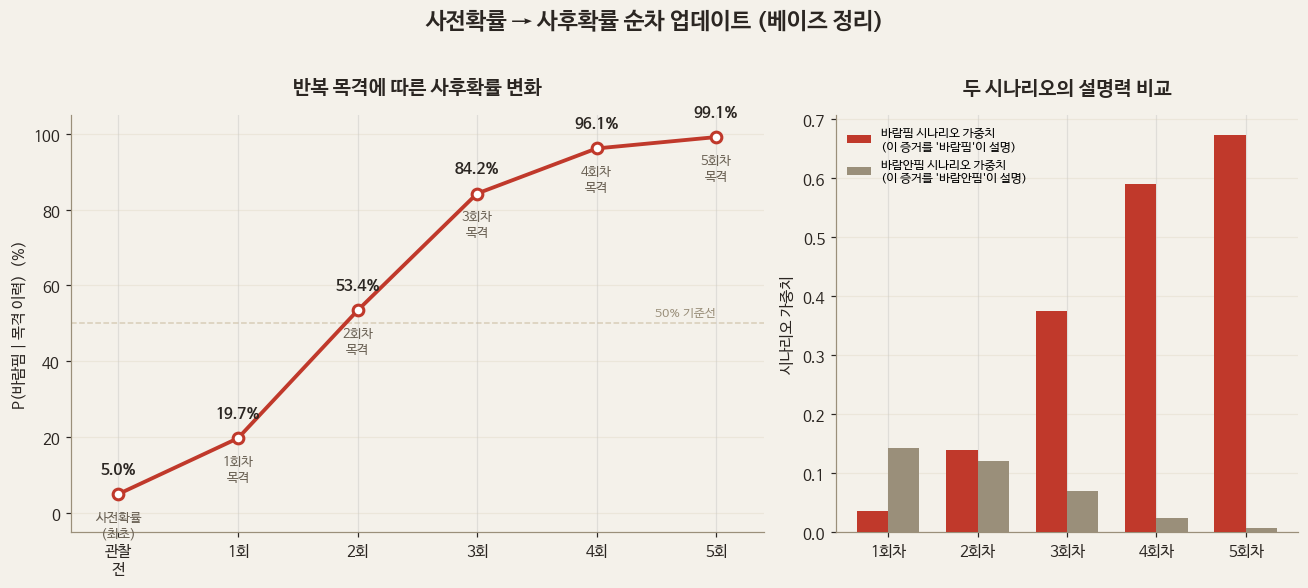

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ------------------------------------------------------------------
# 1. 베이즈 업데이트 함수
# ------------------------------------------------------------------
def bayes_update(prior: float, p_e_given_h: float, p_e_given_not_h: float) -> float:
    """
    prior           : P(바람핌)            - 이번 단계의 사전확률
    p_e_given_h     : P(휴대폰 숨김|바람핌)  - likelihood
    p_e_given_not_h : P(휴대폰 숨김|바람안핌) - likelihood
    반환값           : P(바람핌|휴대폰 숨김)  - 사후확률
    """
    weight_cheat = p_e_given_h * prior              # '바람핌' 시나리오 가중치
    weight_not_cheat = p_e_given_not_h * (1 - prior)  # '바람안핌' 시나리오 가중치
    return weight_cheat / (weight_cheat + weight_not_cheat)


def run_sequence(prior0: float, p_e_h: float, p_e_not_h: float, n_steps: int):
    """n_steps번 같은 단서를 반복 관찰했을 때의 사전/사후확률 시퀀스를 반환"""
    priors, posteriors = [], []
    cur = prior0
    for _ in range(n_steps):
        priors.append(cur)
        post = bayes_update(cur, p_e_h, p_e_not_h)
        posteriors.append(post)
        cur = post  # 오늘의 사후확률 -> 내일의 사전확률
    return np.array(priors), np.array(posteriors)


# ------------------------------------------------------------------
# 2. 파라미터 및 계산
# ------------------------------------------------------------------
PRIOR0 = 0.05        # 최초 사전확률 P(바람핌)
P_E_GIVEN_H = 0.70    # P(휴대폰 숨김 | 바람핌)
P_E_GIVEN_NOT_H = 0.15  # P(휴대폰 숨김 | 바람안핌)
N_STEPS = 5

priors, posteriors = run_sequence(PRIOR0, P_E_GIVEN_H, P_E_GIVEN_NOT_H, N_STEPS)
steps = np.arange(1, N_STEPS + 1)

# 콘솔에 표 형태로 출력
print(f"{'단계':>4} | {'사전확률':>10} | {'사후확률':>10} | {'증가폭(%p)':>10}")
print("-" * 46)
for i, (pr, po) in enumerate(zip(priors, posteriors), start=1):
    delta = (po - pr) * 100
    print(f"{i:>4} | {pr*100:>9.1f}% | {po*100:>9.1f}% | {delta:>9.1f}")

# ------------------------------------------------------------------
# 3. 시각화
# ------------------------------------------------------------------
INK = "#2b2622"
ACCENT = "#c0392b"
GRID = "#d8cdb8"
BG = "#f4f1ea"

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 5.2), gridspec_kw={"width_ratios": [1.5, 1]}
)
fig.patch.set_facecolor(BG)

# --- (좌) 사후확률 누적 곡선 ---
ax1.set_facecolor(BG)
x_full = np.concatenate([[0], steps])
y_full = np.concatenate([[PRIOR0], posteriors])

ax1.plot(x_full, y_full * 100, color=ACCENT, linewidth=2.5, marker="o",
         markersize=7, markerfacecolor="white", markeredgecolor=ACCENT,
         markeredgewidth=2, zorder=3)

for x, y in zip(x_full, y_full):
    label = "사전확률\n(최초)" if x == 0 else f"{x}회차\n목격"
    ax1.annotate(f"{y*100:.1f}%", (x, y * 100), textcoords="offset points",
                 xytext=(0, 14), ha="center", fontsize=10, color=INK, fontweight="bold")
    ax1.annotate(label, (x, y * 100), textcoords="offset points",
                 xytext=(0, -28), ha="center", fontsize=8.5, color="#6b6255")

ax1.axhline(50, color=GRID, linestyle="--", linewidth=1, zorder=1)
ax1.text(x_full[-1], 52, "50% 기준선", fontsize=8, color="#9a8f7a", ha="right")

ax1.set_ylim(-5, 105)
ax1.set_xlim(-0.4, N_STEPS + 0.4)
ax1.set_xticks(x_full)
ax1.set_xticklabels(["관찰\n전"] + [f"{s}회" for s in steps])
ax1.set_ylabel("P(바람핌 | 목격 이력)  (%)", fontsize=10, color=INK)
ax1.set_title("반복 목격에 따른 사후확률 변화", fontsize=13, color=INK, fontweight="bold", pad=14)
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax1.spines[spine].set_color("#9a8f7a")
ax1.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
ax1.tick_params(colors=INK)

# --- (우) 두 시나리오의 '가중치' 비교 ---
# '바람핌 시나리오 가중치'  = P(숨김|바람핌) × P(바람핌)     -> 이 증거를 '바람핌'이 얼마나 잘 설명하는가
# '바람안핌 시나리오 가중치' = P(숨김|바람안핌) × P(바람안핌)  -> 이 증거를 '바람안핌'이 얼마나 잘 설명하는가
# 사후확률 = 바람핌 가중치 / (바람핌 가중치 + 바람안핌 가중치)
ax2.set_facecolor(BG)
width = 0.35
weight_cheat = P_E_GIVEN_H * priors
weight_not_cheat = P_E_GIVEN_NOT_H * (1 - priors)

ax2.bar(steps - width / 2, weight_cheat, width, label="바람핌 시나리오 가중치\n(이 증거를 '바람핌'이 설명)",
        color=ACCENT, zorder=3)
ax2.bar(steps + width / 2, weight_not_cheat, width, label="바람안핌 시나리오 가중치\n(이 증거를 '바람안핌'이 설명)",
        color="#9a8f7a", zorder=3)

ax2.set_xticks(steps)
ax2.set_xticklabels([f"{s}회차" for s in steps])
ax2.set_ylabel("시나리오 가중치", fontsize=10, color=INK)
ax2.set_title("두 시나리오의 설명력 비교", fontsize=13, color=INK, fontweight="bold", pad=14)
ax2.legend(fontsize=8, frameon=False, loc="upper left")
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax2.spines[spine].set_color("#9a8f7a")
ax2.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
ax2.tick_params(colors=INK)

fig.suptitle("사전확률 → 사후확률 순차 업데이트 (베이즈 정리)", fontsize=15,
             color=INK, fontweight="bold", y=1.02)
fig.tight_layout()

plt.show()
